<a href="https://colab.research.google.com/github/suvorovDm-1/ML_course/blob/main/HW3_Suvorov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Анализ и классификация качества вина с использованием методов машинного обучения**

Этот датасет содержит данные о химических и физических характеристиках образцов красного и белого вина.

В нём собраны такие показатели, как кислотность, количество остаточного сахара, плотность, содержание алкоголя и уровень диоксида серы.

Эти данные были получены в результате лабораторных измерений, а также экспертных оценок качества вина по шкале от 3 до 9.

Задача состоит в том, что необходимо понять, как разные свойства вина влияют на его качество, и научиться предсказывать оценку напитка по этим характеристикам с помощью методов машинного обучения.

## **1. Чтение данных:**

In [638]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [639]:
# from google.colab import files
# uploaded = files.upload()

In [640]:
data = pd.read_csv("wine_quality.csv", sep=',')

In [641]:
data.shape # Размер данных (<строки>, <столбцы>)

(6497, 13)

In [642]:
for col in data.columns:
    print(col) # Столбцы таблицы датасета (Представленные признаки)

fixed acidity
volatile acidity
citric acid
residual sugar
chlorides
free sulfur dioxide
total sulfur dioxide
density
pH
sulphates
alcohol
quality
type


***Описание признаков:***
*   'fixed acidity' – Содержание постоянных кислот (например, винная, яблочная) в вине.
*   'volatile acidity' – Содержание летучих кислот (например, уксусной), которые сильно влияют на вкус.
*   'citric acid' – Количество лимонной кислоты.
*   'residual sugar' – Остаточный сахар, оставшийся после ферментации.
*   'chlorides' – Содержание хлоридов, влияет на солёность/вкус.
*   'free sulfur dioxide'– Свободный диоксид серы, предотвращает порчу вина.
*   'total sulfur dioxide' – Общее количество диоксида серы (свободного + связанного).
*   'density' – Плотность вина, зависит от содержания сахара и алкоголя.
*   'pH' – Кислотность/щелочность вина.
*   'sulphates' – Содержание сульфатов, влияет на вкус и консервацию.
*   'alcohol' – Содержание алкоголя (%).
*   'quality' – Оценка качества вина по шкале от 3 до 9 (экспертная оценка)
*   'type' – Тип вина: красное или белое.











In [643]:
data # Вывод всех данных в виде таблицы

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


Краткая информация о датасете и его признаках:

In [644]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [645]:
data.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
3604,7.0,0.280,0.33,14.6,0.043,47.0,168.0,0.99940,3.34,0.67,8.8,6,white
4459,7.3,0.210,0.33,1.0,0.037,66.0,144.0,0.99230,3.11,0.52,10.2,6,white
1352,7.6,0.645,0.03,1.9,0.086,14.0,57.0,0.99690,3.37,0.46,10.3,5,red
5375,6.9,0.330,0.31,7.7,0.040,29.0,135.0,0.99226,3.11,0.57,12.3,5,white
3679,6.8,0.360,0.32,1.6,0.039,10.0,124.0,0.99480,3.30,0.67,9.6,5,white
219,7.8,0.530,0.33,2.4,0.080,24.0,144.0,0.99655,3.30,0.60,9.5,5,red
1257,7.0,0.580,0.28,4.8,0.085,12.0,69.0,0.99633,3.32,0.70,11.0,6,red
4478,5.7,0.370,0.30,1.1,0.029,24.0,88.0,0.98883,3.18,0.39,11.7,6,white
3251,8.2,0.290,0.49,1.0,0.044,29.0,118.0,0.99280,3.24,0.36,10.9,4,white
2637,7.1,0.150,0.34,5.3,0.034,33.0,104.0,0.99530,3.37,0.52,9.3,7,white


In [646]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [647]:
data.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white
6496,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,white


## **2. Разбиение данных на обучающую и тестовую выборки:**

Необходимо разделить датасет на две выборки: обучающую и тестовую.
- **обучающая выборка** (train set) - будет использоваться для построения модели;
- **тестовая выборка** (test set) - будет использоваться для проверки качества работы модели на новых данных.
Разбиение проведем в отношении 3:1 соответственно.

In [648]:
from sklearn.model_selection import train_test_split

X = data.drop(['quality'], axis=1)
y = data['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

N_train, _ = X_train.shape
N_test, _ = X_test.shape

In [649]:
N_train # Размер обучающей выборки

4872

In [650]:
N_test # Размер тестовой выборки

1625

## **3. Визуализация данные и вычисление основных характеристик**

На данном этапе проведём первичный анализ данных (EDA - Exploratory Data Analysis - разведочного анализа данных):
 - Посмотрим на статистические характеристики признаков (среднее, стандартное отклонение, минимальные и максимальные значения, квантили и т.п.);
 - Построим и проанализируем матрицу корреляций, чтобы увидеть, какие признаки наиболее связаны между собой и с целевой переменной `quality`;
 - Визуализируем распределения нескольких признаков, чтобы оценить форму распределения, а также наличие выбросов.

В рамках анализа будем рассматривать датасет целиком, а не обучающую выборку, т.к. цель анализа - изучить структуру данных в целом.

Основные статистические характеристики всех числовых признаков:
- count — количество непустых (непропущенных) значений
- mean — среднее значение признака
- std — стандартное отклонение (показывает разброс значений)
- min — минимальное значение
- 25% — первый квартиль (значение, ниже которого находится 25% данных)
- 50% — медиана (второй квартиль, середина распределения)
- 75% — третий квартиль (значение, ниже которого находится 75% данных)
- max — максимальное значение

In [651]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


Также рассмотрим отдельно один признак, который не попал в таблицу выше, т.к. является категориальным:

In [652]:
data['type'] = data['type'].astype('category')
data['type'].dtype

CategoricalDtype(categories=['red', 'white'], ordered=False, categories_dtype=object)

Теперь построим корреляционную матрицу:

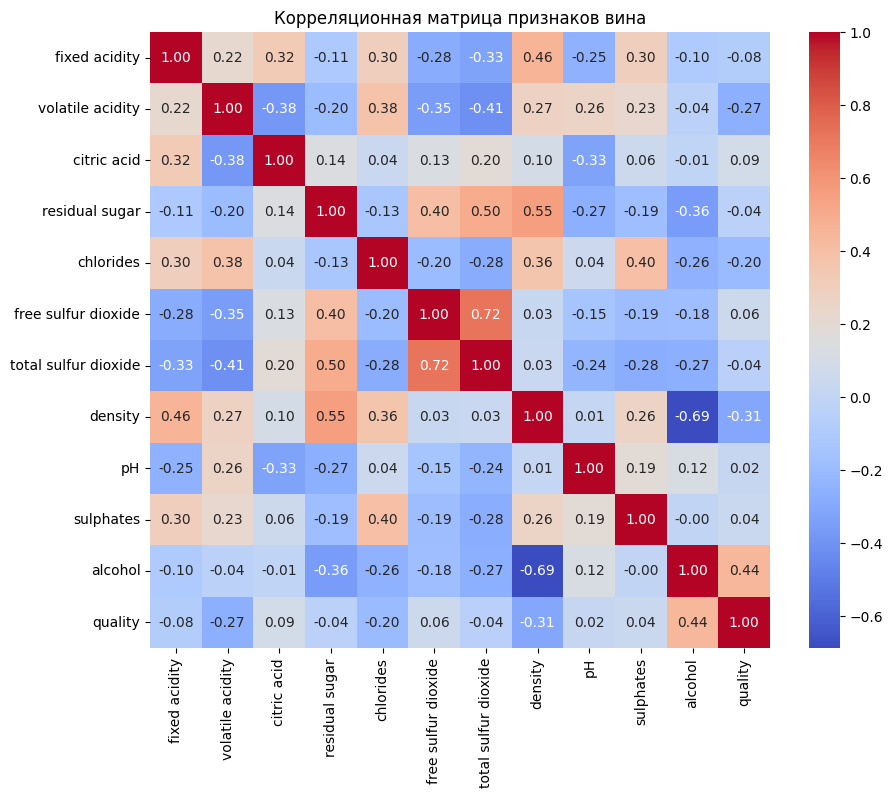

In [653]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Корреляционная матрица признаков вина')
plt.show()

In [654]:
corr_mat = data.corr(numeric_only=True)
corr_mat.where(np.triu(np.abs(corr_mat) > 0.5, k=1)).stack().sort_values(ascending=False)

,,0
free sulfur dioxide,total sulfur dioxide,0.720934
residual sugar,density,0.552517
density,alcohol,-0.686745


Как из визуализации матрицы корреляции, так и из фильтра по значениям модуля корреляции выше нижней границы 0.5 видны пары признаков, обладающие наибольшей корреляцией с друг другом по модулю:
 - Сильная положительная корреляция количества свободного диоксида серы и общего количества диоксида серы логична
 - Умеренная корреляция сахара и плотности напитка также объяснима. Сахар одно их наиболее влияющих на плотность напитка признаков.
 - Сильная отрицательная корреляция содержания алкоголя и плотность также легко объяснима. Алкоголь имеет меньшую плотность, чем вода. Значит при увеличении содержания алкоголя - плотность снижается.

Но, нас больше интересует корреляция признаков с целевым признаком - качеством ('quality')

In [655]:
corr_with_quality = data.corr(numeric_only=True)['quality']
top5_corr = corr_with_quality.reindex(corr_with_quality.abs().sort_values(ascending=False).index)
top5_corr = top5_corr.drop('quality', errors='ignore').head(4)
top5_corr

,quality
alcohol,0.444319
density,-0.305858
volatile acidity,-0.265699
chlorides,-0.200666


Сверху выведены 4 признака, которые имеют наибольшую по модулю корреляцию с оценкой качества вина. Эксперементально подобрано число 4, т.к. у остальных признаков корреляция с качеством по модулю менее 10%!

Получившиеся результаты легко пояснить:

Анализ корреляций показал, что качество вина положительно связано с содержанием алкоголя и отрицательно — с плотностью, летучей кислотностью и содержанием хлоридов.

Более высокие оценки, как правило, получают вина с большим содержанием алкоголя, что делает их более полнотелыми и насыщенными. Пониженная плотность может косвенно указывать на меньшую сладость и отсутствие добавок, что отражает «чистоту» состава вина. Низкая летучая кислотность и умеренное количество хлоридов соответствуют сбалансированному вкусу, без чрезмерной кислоты или солёности (а также без других нежелательных для оттенков вкуса, которые придают хлориды).

<Axes: xlabel='alcohol', ylabel='quality'>

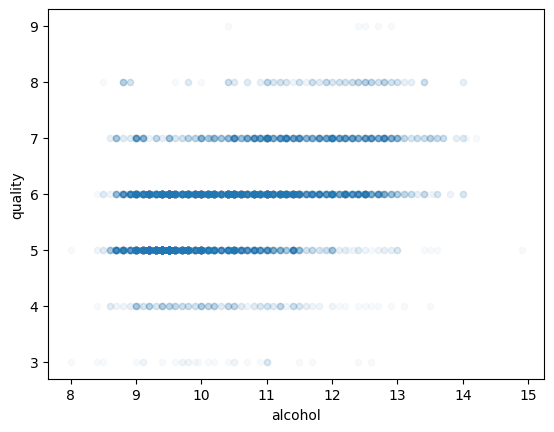

In [656]:
data.plot(kind='scatter', x='alcohol', y='quality', alpha=0.03)

Проанализировав диаграмму рассеивания по двум признакам (алкоголь и качество) легко заметить, что с увеличением содержания алкоголя наблюдается тенденция к повышению качества, что подтверждает положительную корреляцию.

<Axes: xlabel='quality', ylabel='alcohol'>

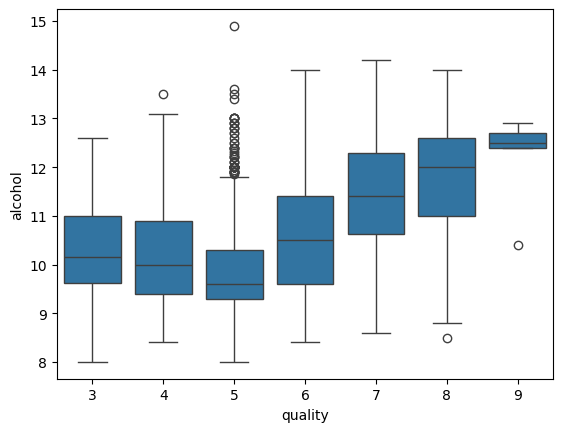

In [657]:
sns.boxplot(x='quality', y='alcohol', data=data)

<Axes: xlabel='quality', ylabel='alcohol'>

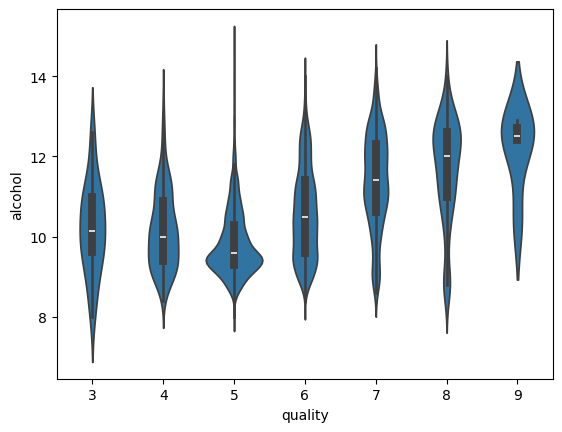

In [658]:
sns.violinplot(x='quality', y='alcohol', data=data)

Еще два приведенных выше вида диаграм ("ящик с усами" и "скрипичный график") также очень наглядно демонстрируют довольно сильную положительную корреляцию между алкоголем и оценкой качества.

Однако, по этим диаграммам видно, что зависимость алкоголя от качества вина не строго линейная, а немного "U" образная.

В целом, более высокое качество связано с большим содержанием алкоголя. Однако на низких уровнях качества наблюдается противоположная тенденция: основная масса вин с оценкой 3 имеют чуть более высокий алкоголь, чем основная масса вин с оценкой 5.



In [659]:
data['quality'].value_counts()

,count
quality,
6,2836
5,2138
7,1079
4,216
8,193
3,30
9,5


Проанализировав распределение количества вин по каждой оценке, можно предположить, что наблюдаемая «аномалия» на низких оценках (3 и 5) может быть связана с малым количеством вин в категории 3 и большим количеством в категории 5. В маленькой категории 3 даже несколько крепких вин существенно влияют на медиану, тогда как в большой категории 5 основная масса вин более лёгкая, поэтому медиана ниже.
Это отражает естественную несбалансированность датасета по качеству.

## **4. Проверка на наличие пропущенных значений:**

In [660]:
data.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


По таблице выше видно, что пропущенных значений в этом датасете нет

## **5. Обработка категориальных признаки**

В моем датасете один категориальный бинарный признак: тип вина.

In [661]:
data.describe(include=['category'])

,type
count,6497
unique,2
top,white
freq,4898


In [662]:
data['type'].unique()

['red', 'white']
Categories (2, object): ['red', 'white']

Произведем **бинаризацию** данного категориального бинарного признака. Для этого заменим тип 'red' на числовое значение 0, а тип 'white' на числовое значение 1.

In [663]:
X_train['type_encoded'] = X_train['type'].map({'red': 0, 'white': 1})
X_train = X_train.drop('type', axis=1)  # можно удалить старый столбец
X_train.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_encoded
3568,6.3,0.41,0.30,3.2,0.030,49.0,164.0,0.99270,3.53,0.79,11.7,1
3181,8.4,0.24,0.49,7.4,0.039,46.0,108.0,0.99340,3.03,0.33,11.9,1
2416,6.6,0.56,0.22,8.9,0.034,27.0,133.0,0.99675,3.20,0.51,9.1,1
3106,7.8,0.26,0.74,7.5,0.044,59.0,160.0,0.99600,3.22,0.64,10.0,1
5267,6.5,0.27,0.26,11.0,0.030,2.0,82.0,0.99402,3.07,0.36,11.2,1
5560,7.6,0.39,0.46,11.7,0.084,55.0,170.0,0.99773,2.91,0.51,9.0,1
340,12.2,0.34,0.50,2.4,0.066,10.0,21.0,1.00000,3.12,1.18,9.2,0
494,6.5,0.39,0.23,8.3,0.051,28.0,91.0,0.99520,3.44,0.55,12.1,0
5729,6.8,0.29,0.32,1.8,0.032,18.0,130.0,0.99095,3.05,0.62,11.2,1
1774,6.9,0.23,0.40,7.5,0.040,50.0,151.0,0.99270,3.11,0.27,11.4,1


In [664]:
X_test['type_encoded'] = X_test['type'].map({'red': 0, 'white': 1})
X_test = X_test.drop('type', axis=1)
X_train.sample(10)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_encoded
3500,7.4,0.21,0.30,7.90,0.039,14.0,118.0,0.99420,2.96,0.34,10.4,1
4730,6.3,0.35,0.26,17.60,0.061,59.0,198.0,0.99918,3.11,0.49,8.8,1
1311,6.5,0.51,0.15,3.00,0.064,12.0,27.0,0.99290,3.33,0.59,12.8,0
1693,7.5,0.17,0.32,1.70,0.040,51.0,148.0,0.99160,3.21,0.44,11.5,1
3314,6.5,0.18,0.34,1.60,0.040,43.0,148.0,0.99120,3.32,0.59,11.5,1
5351,6.5,0.26,0.34,1.40,0.040,25.0,184.0,0.99216,3.29,0.46,10.7,1
4723,6.5,0.24,0.39,17.30,0.052,22.0,126.0,0.99888,3.11,0.47,9.2,1
4623,7.0,0.13,0.37,12.85,0.042,36.0,105.0,0.99581,3.05,0.55,10.7,1
6028,6.1,0.31,0.34,2.80,0.042,59.5,162.0,0.99179,3.27,0.47,10.8,1
2511,6.3,0.34,0.19,5.80,0.041,22.0,145.0,0.99430,3.15,0.63,9.9,1


## **6. Нормализация количественных признаков**

В нашем датасете числовые признаки имеют разные диапазоны значений (например, `residual sugar` от 0.6 до 65.8, `pH` от 2.7 до 4.0, `alcohol` от 8 до 14.9).  
Чтобы алгоритмы, чувствительные к масштабу признаков, корректно учитывали все признаки, необходимо привести их к сопоставимому масштабу.  

Для этого применена **стандартизация**, которая переводит каждый признак в шкалу с **нулевым средним и единичным стандартным отклонением**:

$$
x' = \frac{x - \text{mean}(x)}{\text{std}(x)}
$$

После стандартизации все числовые признаки имеют одинаковый масштаб, что улучшает качество обучения моделей.

In [665]:
numerical_columns   = [
 'fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol'
]
mean = X_train[numerical_columns].mean(axis=0)
std = X_train[numerical_columns].std(axis=0)
X_train_scaled = (X_train[numerical_columns] - mean) / std
X_train_scaled['type_encoded'] = X_train['type_encoded']
X_train_scaled.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_encoded
count,4.872000e+03,4.872000e+03,4.872000e+03,4.872000e+03,4.872000e+03,4.872000e+03,4.872000e+03,4.872000e+03,4.872000e+03,4.872000e+03,4.872000e+03,4872.000000
mean,-3.755434e-16,1.130276e-16,2.118357e-16,8.714066e-17,2.792876e-16,-6.125368e-17,1.159445e-16,5.543458e-15,9.683916e-16,-5.498247e-16,1.662600e-16,0.760878
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.426591
min,-2.639043e+00,-1.586556e+00,-2.215903e+00,-1.015521e+00,-1.380507e+00,-1.702568e+00,-1.966904e+00,-2.506197e+00,-2.981505e+00,-2.097235e+00,-2.084291e+00,0.000000
25%,-6.193358e-01,-6.580151e-01,-4.861600e-01,-7.646739e-01,-5.198573e-01,-7.840242e-01,-6.605810e-01,-7.838156e-01,-6.671500e-01,-6.775615e-01,-8.289299e-01,1.000000
50%,-1.532495e-01,-2.865987e-01,-7.102170e-02,-5.138265e-01,-2.527590e-01,-9.511607e-02,3.731764e-02,6.907833e-02,-4.164873e-02,-1.367334e-01,-1.594041e-01,1.000000
75%,3.128368e-01,3.943313e-01,4.824960e-01,5.731788e-01,2.517600e-01,6.009682e-01,7.173214e-01,7.494022e-01,6.464027e-01,4.716982e-01,6.775033e-01,1.000000
max,6.527321e+00,7.698853e+00,6.294432e+00,1.261385e+01,1.648540e+01,6.650442e+00,4.081551e+00,1.470766e+01,4.962362e+00,9.800983e+00,3.104535e+00,1.000000


Тестовую выборку необходимо масштабировать аналогичным образом, но обязательно использовуя среднее и отклонение, полученные на обучающей выборке!

In [666]:
X_test_scaled = (X_test[numerical_columns] - mean) / std
X_test_scaled['type_encoded'] = X_test['type_encoded']

## **7. Запуск классификатора: kNN**

In [667]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 10)
knn.fit(X_train_scaled, y_train)
knn

KNeighborsClassifier(n_neighbors=10)

## **8.1 Рассмотрим ошибку на обучающей и тестовой выборке:**

In [668]:
err_train = 1 - knn.score(X_train_scaled, y_train)
err_test = 1 - knn.score(X_test_scaled, y_test)
print(f"Ошибка на обучающей выборке: {err_train:.3f}")
print(f"Ошибка на тестовой выборке: {err_test:.3f}")

Ошибка на обучающей выборке: 0.365
Ошибка на тестовой выборке: 0.450


## **8.2 Матрицы рассогласования:**

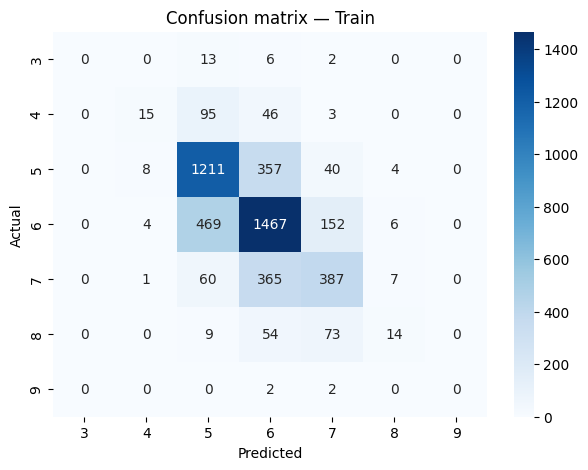

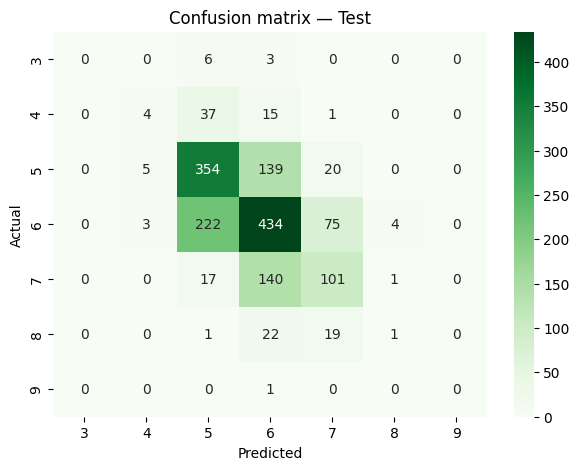

In [669]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = [3, 4, 5, 6, 7, 8, 9]

y_train_pred = knn.predict(X_train_scaled)
y_test_pred  = knn.predict(X_test_scaled)

# Матрица для обучающей выборки
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — Train")
plt.show()

# Матрица для тестовой выборки
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — Test")
plt.show()


На матрицах наглядно видны последствия сильной несбалансированности классов. Основная масса вин имеют оценки 5, 6 или 7. Остальные оценки выставлены сравнительно небольшому количеству вин. Как раз для оценок 5, 6 и 7 замечаем выраженные диагональные значения, т.е. угаданные правильно. Для остальных же, редких классов точность заметно ниже. Например, для прогнозируемой оценки 4 модель правильно угадала 4 вина, но при этом 5 вин с оценкой 5 были ошибочно классифицированы как 4, а 3 вина с оценкой 6 — также как 4. Это дает нам понять, что редкие классы почти не распознаются корректно из-за их низкой представленности в выборке.

Также видно, что самые редкие классы "3" и "9" - "поглотились". Дело в том, что в kNN объекты классифицируются по большинству ближайших соседей, и редкие классы «теряются» среди более многочисленных классов (таким как 5, 6 и 7). Так что мы наблюдаемый еще одно последствие сильной несбалонсированности классов.

## **8.3 Подбор параметров:**

Наша модель верно предсказывает оценку качества вина только в 55% случаев. В остальных 45% ошибается.

Для улучшения результата попробуем провести подбор параметра 'n_neighbors'

In [670]:
from sklearn.model_selection import GridSearchCV
knn = KNeighborsClassifier()
params = {'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 20, 25]}
grid = GridSearchCV(knn, params, cv=3)
grid.fit(X_train_scaled, y_train)
print("Лучшее число соседей:", grid.best_params_)
print("Лучшее качество:", grid.best_score_)

Лучшее число соседей: {'n_neighbors': 1}
Лучшее качество: 0.5769704433497537


In [671]:
knn = KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'], weights='distance')
knn.fit(X_train_scaled, y_train)
err_train = 1 - knn.score(X_train_scaled, y_train)
err_test  = 1 - knn.score(X_test_scaled, y_test)
print(f"Точность на обучающей выборке: {1-err_train:.3f}")
print(f"Точность на тестовой выборке: {1-err_test:.3f}")

Точность на обучающей выборке: 1.000
Точность на тестовой выборке: 0.601


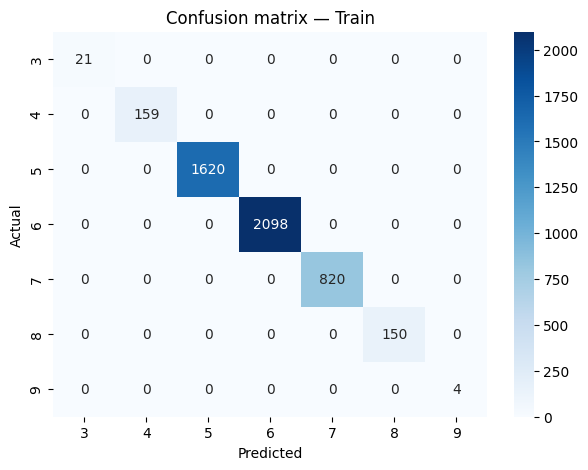

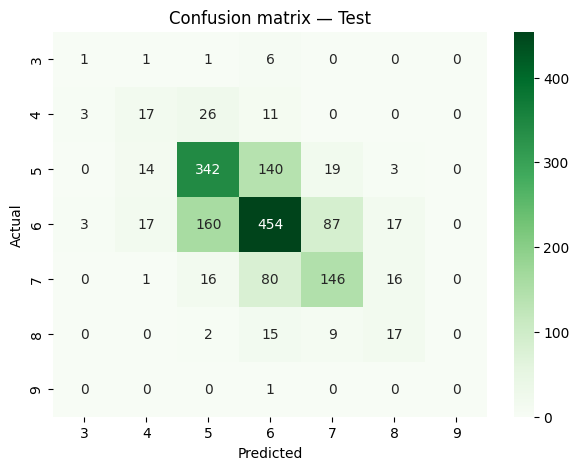

In [672]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = [3, 4, 5, 6, 7, 8, 9]

y_train_pred = knn.predict(X_train_scaled)
y_test_pred  = knn.predict(X_test_scaled)

# Матрица для обучающей выборки
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — Train")
plt.show()

# Матрица для тестовой выборки
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — Test")
plt.show()

После подбора параметра видно, что:
Точность на обучающей выборке: 100%
Точность на тестовой выборке: 60%
Разница указывает на **переобучение** и **сильную несбалансированность классов** (многие вина имеют оценки 5–7, редкие классы 3 и 9 почти не предсказываются)


## **9+10. Запуск другого классификатора: RandomForest с учитванием несбалансированности классов**

In [675]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced' # !!!учитываем несбалансированные классы!!!
)

rf.fit(X_train_scaled, y_train)

y_train_pred = rf.predict(X_train_scaled)
y_test_pred  = rf.predict(X_test_scaled)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test  = accuracy_score(y_test, y_test_pred)

print(f"RandomForest - точность на train: {acc_train:.3f}")
print(f"RandomForest - точность на test : {acc_test:.3f}")


RandomForest - точность на train: 1.000
RandomForest - точность на test : 0.678


Точность предсказаний увеличилась. RandomForest лучше справляется с несбалансированностью классов и учитывает сложные нелинейные взаимодействия между признаками. В свою очередь, kNN чувствителен к редким классам. Это и позволило RF получить 67,8% точность классификации, а kNN - 60,1%.


Feature ranking:
 1. feature 'alcohol' (0.116641)
 2. feature 'chlorides' (0.108762)
 3. feature 'density' (0.108513)
 4. feature 'free sulfur dioxide' (0.099462)
 5. feature 'volatile acidity' (0.092853)
 6. feature 'fixed acidity' (0.086749)
 7. feature 'residual sugar' (0.082924)
 8. feature 'total sulfur dioxide' (0.082773)
 9. feature 'pH' (0.075888)
10. feature 'sulphates' (0.070732)
11. feature 'citric acid' (0.070716)
12. feature 'type_encoded' (0.003987)


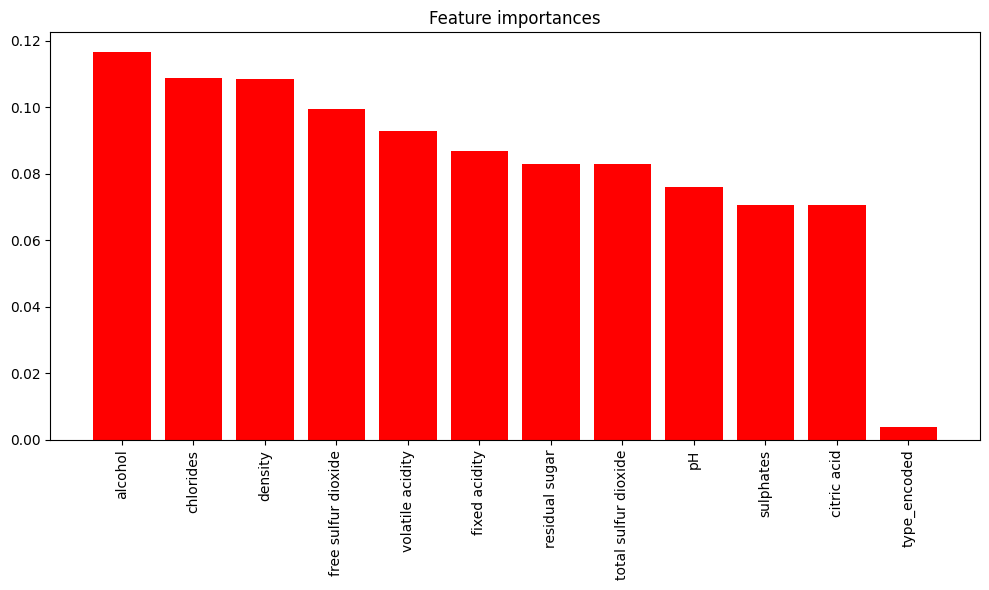

In [678]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X_train_scaled.columns.tolist()
d = len(feature_names)

print("\nFeature ranking:")
for f in range(d):
    print("%2d. feature '%s' (%f)" % (f + 1, feature_names[indices[f]], importances[indices[f]]))

d_first = min(20, d)
plt.figure(figsize=(10,6))
plt.title("Feature importances")
plt.bar(range(d_first), importances[indices[:d_first]], align='center', color='r')
plt.xticks(range(d_first), [feature_names[i] for i in indices[:d_first]], rotation=90)
plt.xlim([-1, d_first])
plt.tight_layout()
plt.show()

По диаграме значимости признаков видно, что наибольший вклад в предсказание качества имеют химические характеристики вина — alcohol, chlorides, density, free sulfur dioxide и кислотность. Это соответствует результатам полученным ранее с помощью матрицы корреляции.

Заметим, что бинарный признак type практически не влияет на предсказание качества вина. Это логично: цвет вина (белое или красное) мало определяет его оценку по химическим характеристикам и вкусу.

# **12. Общие выводы:**

В рамках проведённого исследования были обучены и протестированы модели **kNN** и **RandomForest** для предсказания качества вина на основе физико-химических характеристик. Основные выводы можно структурировать следующим образом:

 ---

 ## 1. Влияние признаков на качество вина
 Исходя из полученных результатов матрицы корреляции и значимости признаков, наиболее значимыми для предсказания качества оказались: содержание алкоголя, плотность, кислотность и концентрация хлоридов. Это согласуется с ожидаемой физико-химической взаимосвязью, т.к. именно эти признаки больше всего влияют на вкус. Остальные признаки оказывают умеренное или слабое влияние на качество. В свою очередь цвет вина практически не оказывает влияния на качество (его влияние в разы меньше влияния любых других признаков на качество).

 ---

 ## 2. Особенности датасета
 Датасет обладает ярко выраженной несбалансированностью классов, что приводит к преобладанию среднего качества вина. Такая структура данных усложняет обучение моделей, особенно для редких классов, и требует применения специальных подходов к балансировке, например, взвешивания классов.

 ---

 ## 3. Оценка моделей

 - **kNN:** оказался сильно чувствителен к параметрам и сильно переобучился на тренировочных данных. При этом на тестовой выборке продемонстрировал умеренное качество. Это указывает на то, что данная модель несправляется с подобной несбалансированностью.

 - **RandomForest:** продемонстрировал более высокую точность на тестовой выборке и лучшую способность к обобщению. Модель эффективно использует значимость признаков, что позволяет достичь более стабильного предсказания по сравнению с kNN.

 ---

 ## 4. Значимость признаков и интерпретация модели
 Модель RandomForest выделяет несколько ключевых признаков, наиболее критичных для классификации, и практически не учитывает менее информативные параметры. Это делает модель прозрачной и объяснимой, позволяя понимать, какие аспекты вина наиболее существенно влияют на его оценку.

 ---

 **Итог:** анализ показывает, что наилучшие результаты достигаются при использовании моделей, учитывающих значимость признаков и способных адаптироваться к дисбалансу классов. RandomForest проявил себя как более стабильное решение, тогда как kNN требует тщательного подбора параметров и работы с балансом данных.